In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [4]:
species_observations = pd.read_csv('observations.csv')

In [5]:
species_info = pd.read_csv('species_info.csv')

In [6]:
print(species_observations.head())

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85


In [7]:
print(species_observations.describe(include = 'all')) 

         scientific_name                            park_name  observations
count              23296                                23296  23296.000000
unique              5541                                    4           NaN
top     Myotis lucifugus  Great Smoky Mountains National Park           NaN
freq                  12                                 5824           NaN
mean                 NaN                                  NaN    142.287904
std                  NaN                                  NaN     69.890532
min                  NaN                                  NaN      9.000000
25%                  NaN                                  NaN     86.000000
50%                  NaN                                  NaN    124.000000
75%                  NaN                                  NaN    195.000000
max                  NaN                                  NaN    321.000000


In [8]:
print(species_observations.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB
None


In [9]:
species_observations.isnull().sum()

scientific_name    0
park_name          0
observations       0
dtype: int64

In [9]:
print(species_info.head(10))

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   
5   Mammal         Odocoileus virginianus   
6   Mammal                     Sus scrofa   
7   Mammal                  Canis latrans   
8   Mammal                    Canis lupus   
9   Mammal                    Canis rufus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 NaN  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN  
4                                      Wapiti Or Elk                 NaN  
5                                  White-Tailed Deer  

In [10]:
print(species_info.describe())


              category    scientific_name        common_names  \
count             5824               5824                5824   
unique               7               5541                5504   
top     Vascular Plant  Castor canadensis  Brachythecium Moss   
freq              4470                  3                   7   

       conservation_status  
count                  191  
unique                   4  
top     Species of Concern  
freq                   161  


In [11]:
print(species_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
None


In [12]:
species_info.isnull().sum()

category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64

In [13]:
species_info['conservation_status'] = species_info.conservation_status.fillna('Not at risk')

In [14]:
species_info.isnull().sum()

category               0
scientific_name        0
common_names           0
conservation_status    0
dtype: int64

In [15]:
print(species_info.head(10))

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   
5   Mammal         Odocoileus virginianus   
6   Mammal                     Sus scrofa   
7   Mammal                  Canis latrans   
8   Mammal                    Canis lupus   
9   Mammal                    Canis rufus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole         Not at risk  
1                              American Bison, Bison         Not at risk  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...         Not at risk  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)         Not at risk  
4                                      Wapiti Or Elk         Not at risk  
5                                  White-Tailed Deer  

In [16]:
species_info['conservation_status'].value_counts().sum()

np.int64(5824)

In [17]:
status_count = species_info['conservation_status'].value_counts()
status_count

conservation_status
Not at risk           5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64

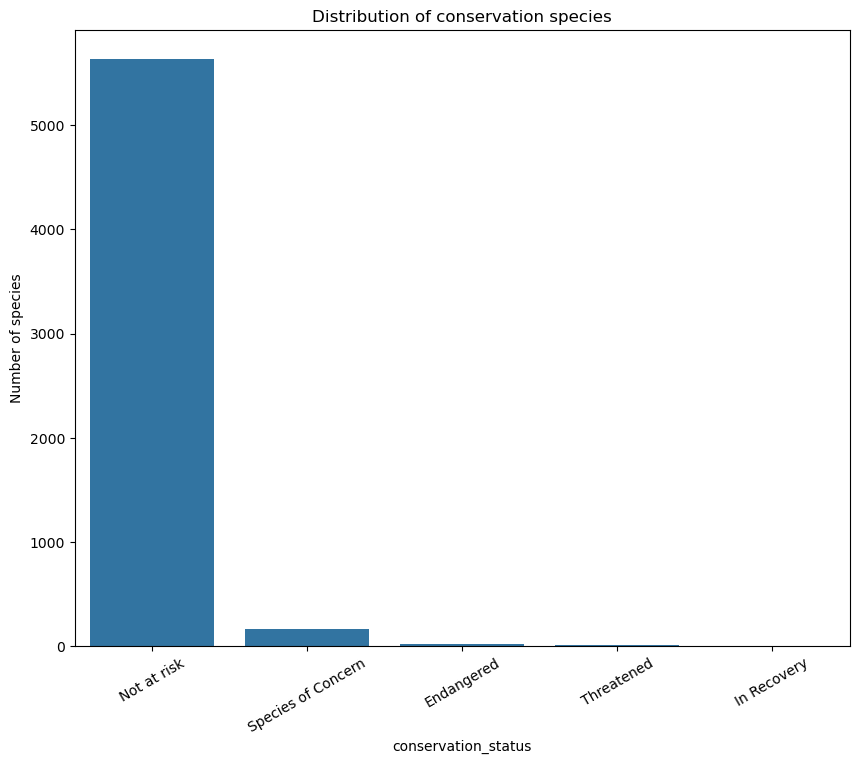

<Figure size 640x480 with 0 Axes>

In [18]:
plt.figure(figsize = (10, 8))
sns.barplot(x = status_count.index, y = status_count.values)
plt.xticks(rotation = 30)
plt.title('Distribution of conservation species')
plt.ylabel('Number of species')
plt.show()
plt.clf()

In [19]:
#most species are not at risk and only few species are endangered and threatened

In [44]:
species_info['is_protected'] = species_info.conservation_status != 'Not at risk'

In [46]:
print(species_info.conservation_status.unique())
print(species_info.head())

['Not at risk' 'Species of Concern' 'Endangered' 'Threatened'
 'In Recovery']
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  \
0                           Gapper's Red-Backed Vole         Not at risk   
1                              American Bison, Bison         Not at risk   
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...         Not at risk   
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)         Not at risk   
4                                      Wapiti Or Elk         Not at risk   

   is_protected  
0         False  
1         False  
2         False  
3         False  
4         False  


In [50]:
category_counts = species_info.groupby(['category','is_protected']).scientific_name.nunique().reset_index()


In [56]:
print(category_counts)

             category  is_protected  scientific_name
0           Amphibian         False               72
1           Amphibian          True                7
2                Bird         False              413
3                Bird          True               75
4                Fish         False              115
5                Fish          True               11
6              Mammal         False              146
7              Mammal          True               30
8   Nonvascular Plant         False              328
9   Nonvascular Plant          True                5
10            Reptile         False               73
11            Reptile          True                5
12     Vascular Plant         False             4216
13     Vascular Plant          True               46


In [58]:
category_pivot = category_counts.pivot(columns = 'is_protected', index = 'category', values = 'scientific_name').reset_index()
category_pivot.columns = ['category', 'not_protected', 'protected']
print(category_pivot)

            category  not_protected  protected
0          Amphibian             72          7
1               Bird            413         75
2               Fish            115         11
3             Mammal            146         30
4  Nonvascular Plant            328          5
5            Reptile             73          5
6     Vascular Plant           4216         46


In [60]:
category_pivot['percent_protected'] = category_pivot.protected/(category_pivot.protected+category_pivot.not_protected)

In [61]:
print(category_pivot)

            category  not_protected  protected  percent_protected
0          Amphibian             72          7           0.088608
1               Bird            413         75           0.153689
2               Fish            115         11           0.087302
3             Mammal            146         30           0.170455
4  Nonvascular Plant            328          5           0.015015
5            Reptile             73          5           0.064103
6     Vascular Plant           4216         46           0.010793


In [63]:
contingency_values = [[30, 146],
                     [75, 413]]
chi2_contingency(contingency_values)

Chi2ContingencyResult(statistic=np.float64(0.1617014831654557), pvalue=np.float64(0.6875948096661336), dof=1, expected_freq=array([[ 27.8313253, 148.1686747],
       [ 77.1686747, 410.8313253]]))

In [64]:
contingency_values = [[30, 146],
                     [5, 73]]
chi2_contingency(contingency_values)

Chi2ContingencyResult(statistic=np.float64(4.289183096203645), pvalue=np.float64(0.03835559022969898), dof=1, expected_freq=array([[ 24.2519685, 151.7480315],
       [ 10.7480315,  67.2519685]]))

In [65]:
print(species_observations.head())

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85


In [70]:
species_info['sheeps'] = species_info.common_names.apply(lambda x : 'Sheep' in x)

In [71]:
print(species_info.head(10))

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   
5   Mammal         Odocoileus virginianus   
6   Mammal                     Sus scrofa   
7   Mammal                  Canis latrans   
8   Mammal                    Canis lupus   
9   Mammal                    Canis rufus   

                                        common_names conservation_status  \
0                           Gapper's Red-Backed Vole         Not at risk   
1                              American Bison, Bison         Not at risk   
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...         Not at risk   
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)         Not at risk   
4                                      Wapiti Or Elk         Not at risk   
5                                  White-Tailed 

In [76]:
species_info[species_info.sheeps]

,category,scientific_name,common_names,conservation_status,is_protected,sheeps
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",Not at risk,False,True
1139,Vascular Plant,Rumex acetosella,"Sheep Sorrel, Sheep Sorrell",Not at risk,False,True
2233,Vascular Plant,Festuca filiformis,Fineleaf Sheep Fescue,Not at risk,False,True
3014,Mammal,Ovis canadensis,"Bighorn Sheep, Bighorn Sheep",Species of Concern,True,True
3758,Vascular Plant,Rumex acetosella,"Common Sheep Sorrel, Field Sorrel, Red Sorrel,...",Not at risk,False,True
3761,Vascular Plant,Rumex paucifolius,"Alpine Sheep Sorrel, Fewleaved Dock, Meadow Dock",Not at risk,False,True
4091,Vascular Plant,Carex illota,"Sheep Sedge, Smallhead Sedge",Not at risk,False,True
4383,Vascular Plant,Potentilla ovina var. ovina,Sheep Cinquefoil,Not at risk,False,True
4446,Mammal,Ovis canadensis sierrae,Sierra Nevada Bighorn Sheep,Endangered,True,True


In [79]:
sheep_species = species_info[(species_info['sheeps'])&(species_info['category']== 'Mammal')]

In [80]:
sheep_species

,category,scientific_name,common_names,conservation_status,is_protected,sheeps
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",Not at risk,False,True
3014,Mammal,Ovis canadensis,"Bighorn Sheep, Bighorn Sheep",Species of Concern,True,True
4446,Mammal,Ovis canadensis sierrae,Sierra Nevada Bighorn Sheep,Endangered,True,True


In [83]:
sheep_observation = species_observations.merge(sheep_species)
print(sheep_observation)

            scientific_name                            park_name  \
0           Ovis canadensis            Yellowstone National Park   
1   Ovis canadensis sierrae            Yellowstone National Park   
2           Ovis canadensis                  Bryce National Park   
3   Ovis canadensis sierrae               Yosemite National Park   
4                Ovis aries               Yosemite National Park   
5   Ovis canadensis sierrae                  Bryce National Park   
6   Ovis canadensis sierrae  Great Smoky Mountains National Park   
7                Ovis aries  Great Smoky Mountains National Park   
8                Ovis aries                  Bryce National Park   
9           Ovis canadensis               Yosemite National Park   
10          Ovis canadensis  Great Smoky Mountains National Park   
11               Ovis aries            Yellowstone National Park   

    observations category                                       common_names  \
0            219   Mammal          

In [85]:
obs_by_park = sheep_observation.groupby('scientific_name').observations.sum().reset_index()
obs_by_park

,scientific_name,observations
0,Ovis aries,542
1,Ovis canadensis,493
2,Ovis canadensis sierrae,153


In [86]:
obs_by_park = sheep_observation.groupby('park_name').observations.sum().reset_index()
obs_by_park

,park_name,observations
0,Bryce National Park,250
1,Great Smoky Mountains National Park,149
2,Yellowstone National Park,507
3,Yosemite National Park,282


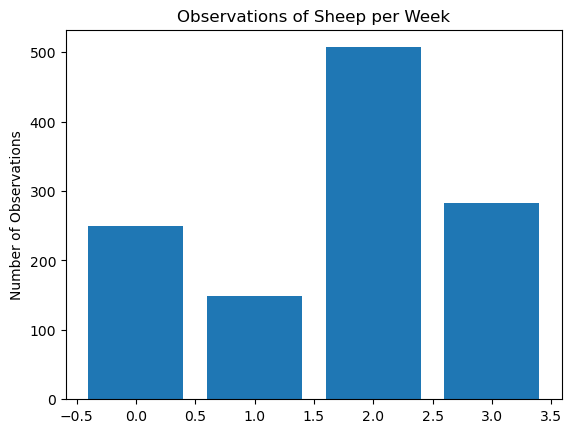

<Figure size 640x480 with 0 Axes>

In [90]:
plt.bar(range(len(obs_by_park)), obs_by_park.observations.values)
ax.set_xticks(range(len(obs_by_park)))
ax.set_xticklabels(obs_by_park.park_name.values)
plt.ylabel('Number of Observations')
plt.title('Observations of Sheep per Week')

plt.show()
plt.clf()